In [1]:
import numpy as np
import torch
from matplotlib import pyplot as plt
from networks.Unets import BnetMean, BnetSmallKernel,BnetSmallKernelSmarter,BnetTiny
from Data.data_operators import BScanDepthDatasetExp
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# %matplotlib widget

In [33]:
def plot_3d_map(tensor2d):
    """
    tensor2d: torch.Tensor or numpy array of shape [H, W]
    values assumed in range [0, 1]
    """
    
    if isinstance(tensor2d, torch.Tensor):
        data = tensor2d.detach().cpu().numpy()
    else:
        data = tensor2d

    H, W = data.shape

    # Create coordinate grid
    x = range(W)
    y = range(H)
    X, Y = torch.meshgrid(torch.tensor(x), torch.tensor(y), indexing="xy")
    X = X.numpy()
    Y = Y.numpy()

    # Plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=30, azim=45)

    ax.plot_surface(X, Y, data, cmap='viridis')

    ax.set_xlabel("Width")
    ax.set_ylabel("Height")
    ax.set_zlabel("Value")

    plt.show()

In [3]:
sim_dataset = BScanDepthDatasetExp(
        bscan_dir=r"/Volumes/KINGSTON/Models_lc_and_test_data/all_data_same_length_no_base_add_noise_test/Test_sample_sim_4mm",
        normalization_path=r"/Volumes/KINGSTON/Models_lc_and_test_data/normalization_params.npz"
    )

In [4]:
exp_dataset = BScanDepthDatasetExp(
        bscan_dir=r"/Volumes/KINGSTON/Two_real_samples/thick_sample_5s/thick_sample_5s_bscans",
        normalization_path=r"/Volumes/KINGSTON/Models_lc_and_test_data/normalization_params.npz"
    )

In [5]:
sim_loader=DataLoader(sim_dataset,batch_size=1,shuffle=False)
exp_loader=DataLoader(exp_dataset,batch_size=1,shuffle=False)

In [6]:
tinynet=BnetTiny()
state_dict=torch.load("/Volumes/KINGSTON/Models_lc_and_test_data/Unet_bnettiny_l2_both_classes.pth",map_location=torch.device('cpu'))
tinynet.load_state_dict(state_dict)
tinynet.eval()

BnetTiny(
  (encoder): TinyEncoder(
    (net): Sequential(
      (0): DSConv(
        (block): Sequential(
          (0): Conv2d(3, 3, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), groups=3, bias=False)
          (1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): GELU(approximate='none')
          (3): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): GELU(approximate='none')
        )
      )
      (1): DSConv(
        (block): Sequential(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): GELU(approximate='none')
          (3): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

In [7]:
meanet=BnetMean()
state_dict=torch.load("/Volumes/KINGSTON/Models_lc_and_test_data/Unet_mean_l2_both_classes.pth",map_location=torch.device('cpu'))
meanet.load_state_dict(state_dict)
meanet.eval()

BnetMean(
  (unet): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNo

In [8]:
kernet=BnetSmallKernel()
state_dict=torch.load("/Volumes/KINGSTON/Models_lc_and_test_data/Unet_small_kernel_l2_both_classes.pth",map_location=torch.device('cpu'))
kernet.load_state_dict(state_dict)
kernet.eval()

BnetSmallKernel(
  (unet): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): 

In [9]:
smartnet=BnetSmallKernelSmarter()
state_dict=torch.load("/Volumes/KINGSTON/Models_lc_and_test_data/Unet_small_kernel_smarter_l2_both_classes.pth",map_location=torch.device('cpu'))
smartnet.load_state_dict(state_dict)
smartnet.eval()

BnetSmallKernelSmarter(
  (unet): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          

In [10]:
sim_data=np.load("/Volumes/KINGSTON/Models_lc_and_test_data/all_data_same_length_no_base_add_noise_test/param_fbh_gaussian_size10mm_depth50pct_thickness3mm.npz",allow_pickle=True)
sim_data['data'].shape

(334, 512, 512)

In [43]:
all_preds = []
with torch.no_grad():
    for batch in exp_loader:
        x = batch  # your batch of inputs
        # pred=tinynet(x)
        # pred = meanet(x)  # shape: [batch_size, ...]
        # pred=kernet(x)
        pred=smartnet(x)
        all_preds.append(pred)

all_preds = torch.cat(all_preds, dim=0)
print(all_preds.shape)

torch.Size([479, 512])


In [44]:
torch.save(all_preds,'smartnet_image_pred_exp.pt')

Text(0.5, 1.0, 'B-net mean network')

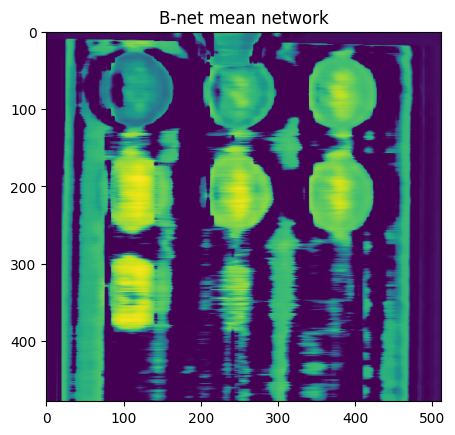

In [45]:
# plt.figure(figsize=(15,5))
# plt.subplot(1,2,1)
# plt.imshow(sim_data['mask'])
# plt.title('Ground truth')

# plt.subplot(1,2,2)
plt.imshow(all_preds)
plt.title('B-net mean network')

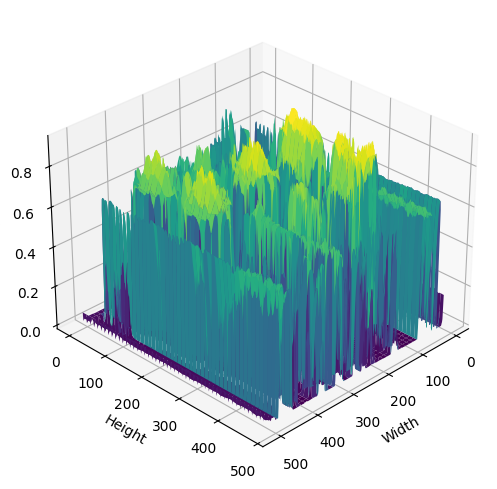

In [46]:
plot_3d_map(all_preds)